In [231]:
##importing libraries
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import random
from mpl_toolkits.mplot3d import Axes3D
import seaborn as sns
from math import ceil
from sklearn.cluster import KMeans #Kmeans cluster package 

In [232]:
#importing data
data = pd.read_csv("cleaned_dataset_without_criticalcolumns.csv")
# check data
print(data.head()) # Prints the first 5 rows of the DataFrame
data.info() #summarize dataframe

         ID  DestAct  NbTransf  TimePT  WalkingTimePT  WaitingTimePT  CostPT  \
0  10350017      2.0         4      85             23             10    12.4   
1  10350125      4.0         1      35             15              4     4.8   
2  10350125     11.0         0      11             10              0     2.2   
3  10350197      1.0         5     124             36             24    11.0   
4  10350199      4.0         4     123             21             59     9.4   

   CostCar  TimeCar  NbHousehold  ...  FreqTripHouseh  Region  distance_km  \
0     3.17       32          2.0  ...             4.0       1         30.0   
1     0.69        9          1.0  ...             3.0       1          7.0   
2     0.13        1          1.0  ...             3.0       1          1.0   
3     2.44       22          2.0  ...             3.0       1         26.0   
4     2.03       19          3.0  ...             2.0       1         22.0   

   Choice  InVehicleTime  ModeToSchool  ReportedDu

In [233]:
target = ['Choice']

# Socio-demographic variables (Sub-question 1)
socio_demo = ['age', 'Gender', 'Education', 'BirthYear', 'LangCode', 'FamilSitu', 'NbHousehold', 'NbChild']

# Vehicle Ownership & Availability (Sub-question 4)
vehicle = ['NbCar', 'NbMoto', 'CarAvail']

# Spatial context (Sub-question 3)
spatial_context = ['UrbRur', 'TypeCommune', 'ClassifCodeLine', 'Region', 'frequency']

# Trip utility (standard predictors for mode choice)
trip_utility = ['TimePT', 'TimeCar', 'InVehicleTime', 'WalkingTimePT', 'WaitingTimePT', 
                'distance_km', 'NbTransf', 'MarginalCostPT', 'CostCar']

# Historical & Childhood Background
history = ['TripPurpose', 'DestAct', 'NbTrajects', 'FreqTripHouseh', 
                      'ModeToSchool', 'ResidChild', 'FreqTrainPar', 'FreqOtherPar']

# Attitudinal Statements (Sub-question 2: Environmental and Lifestyle)
attitudes = ['Envir01', 'Envir05', 'Mobil01', 'Mobil04', 'Mobil08', 'Mobil13', 
             'Mobil15', 'Mobil23', 'ResidCh05', 'ResidCh07', 'LifSty02', 
             'LifSty06', 'LifSty08', 'LifSty11']

critical_cols = target + socio_demo + vehicle + spatial_context + trip_utility + history
critical_data = data[critical_cols]
critical_data.head()

,Choice,age,Gender,Education,BirthYear,LangCode,FamilSitu,NbHousehold,NbChild,NbCar,...,MarginalCostPT,CostCar,TripPurpose,DestAct,NbTrajects,FreqTripHouseh,ModeToSchool,ResidChild,FreqTrainPar,FreqOtherPar
0,1.0,27.0,1.0,7.0,1983.0,1,2.0,2.0,0.0,1.0,...,0.0,3.17,1.0,2.0,2,4.0,3.0,5.0,1.0,1.0
1,1.0,68.0,2.0,3.0,1942.0,1,1.0,1.0,0.0,1.0,...,4.8,0.69,3.0,4.0,1,3.0,4.0,3.0,2.0,2.0
2,1.0,68.0,2.0,3.0,1942.0,1,1.0,1.0,0.0,1.0,...,2.2,0.13,3.0,11.0,1,3.0,4.0,3.0,2.0,2.0
3,1.0,30.0,1.0,8.0,1980.0,1,2.0,2.0,0.0,2.0,...,0.0,2.44,1.0,1.0,2,3.0,1.0,5.0,3.0,1.0
4,1.0,33.0,2.0,6.0,1977.0,1,3.0,3.0,1.0,2.0,...,9.4,2.03,3.0,4.0,1,2.0,5.0,3.0,2.0,1.0


In [234]:
#DATA PROCESSING
X = critical_data.iloc[:,:].values
X = pd.DataFrame(X)
#randomly select a subset of the dataset
#fix the randomness to be able to reproduce
#X = X.sample(n=6000, random_state=1) 
X.columns =  [critical_cols] #attitudes to predict clusters
org_X = X # to keep the version before feature scaling 

# Feature scaling 
X = (X - X.mean()) / X.std()
print(X.head()) # Prints the first 5 rows of the DataFrame

     Choice       age    Gender Education BirthYear  LangCode FamilSitu  \
0  0.347953 -1.480355 -0.912922  1.587249  1.480355 -1.718145 -0.630239   
1  0.347953  1.540733  1.094147 -0.738179 -1.540733 -1.718145 -1.348890   
2  0.347953  1.540733  1.094147 -0.738179 -1.540733 -1.718145 -1.348890   
3  0.347953 -1.259299 -0.912922  2.168606  1.259299 -1.718145 -0.630239   
4  0.347953 -1.038244  1.094147  1.005892  1.038244 -1.718145  0.088412   

  NbHousehold   NbChild     NbCar  ... MarginalCostPT   CostCar TripPurpose  \
0   -0.702065 -0.693095 -0.730376  ...      -0.647460 -0.159031   -1.210342   
1   -1.494459 -0.693095 -0.730376  ...      -0.360469 -0.579474    0.969258   
2   -1.494459 -0.693095 -0.730376  ...      -0.515923 -0.674413    0.969258   
3   -0.702065 -0.693095  0.667277  ...      -0.647460 -0.282790   -1.210342   
4    0.090329  0.297360  0.667277  ...      -0.085437 -0.352299    0.969258   

    DestAct NbTrajects FreqTripHouseh ModeToSchool ResidChild FreqTrainPar

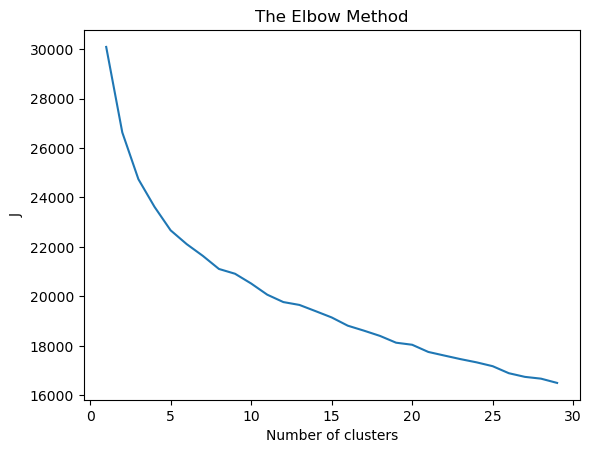

In [235]:
#decide on number of clusters using Elbow method
wcss = []
N_max = 30
for i in range(1, N_max):
    kmeans = KMeans(n_clusters=i, random_state=1, n_init='auto')
    kmeans.fit(X)
    wcss.append(kmeans.inertia_)
    
plt.figure()
plt.plot(range(1, N_max),wcss)
plt.title('The Elbow Method')
plt.xlabel('Number of clusters')
plt.ylabel('J')
plt.show()

In [236]:
#implement kmeans algorithm with 6 clusters based on the outcome of the elbow method
kmeans = KMeans(n_clusters=6, random_state=1, n_init="auto").fit(X)

#add column for clusters
data_cluster = X
data_cluster['Cluster']= kmeans.labels_
data_cluster.head()

,Choice,age,Gender,Education,BirthYear,LangCode,FamilSitu,NbHousehold,NbChild,NbCar,...,CostCar,TripPurpose,DestAct,NbTrajects,FreqTripHouseh,ModeToSchool,ResidChild,FreqTrainPar,FreqOtherPar,Cluster
0,0.347953,-1.480355,-0.912922,1.587249,1.480355,-1.718145,-0.630239,-0.702065,-0.693095,-0.730376,...,-0.159031,-1.210342,-0.611932,0.006683,1.125820,-0.947013,0.645154,-1.442280,-1.462044,4
1,0.347953,1.540733,1.094147,-0.738179,-1.540733,-1.718145,-1.348890,-1.494459,-0.693095,-0.730376,...,-0.579474,0.969258,-0.048637,-1.177630,0.050953,-0.100339,-0.910238,0.048805,-0.125232,5
2,0.347953,1.540733,1.094147,-0.738179,-1.540733,-1.718145,-1.348890,-1.494459,-0.693095,-0.730376,...,-0.674413,0.969258,1.922897,-1.177630,0.050953,-0.100339,-0.910238,0.048805,-0.125232,5
3,0.347953,-1.259299,-0.912922,2.168606,1.259299,-1.718145,-0.630239,-0.702065,-0.693095,0.667277,...,-0.282790,-1.210342,-0.893580,0.006683,0.050953,-2.640361,0.645154,1.539890,-1.462044,4
4,0.347953,-1.038244,1.094147,1.005892,1.038244,-1.718145,0.088412,0.090329,0.297360,0.667277,...,-0.352299,0.969258,-0.048637,-1.177630,-1.023914,0.746334,-0.910238,0.048805,-1.462044,4


In [237]:
data_cluster.columns = [col[0] for col in data_cluster.columns]

In [238]:
#create new datasets per cluster
# Cluster 0
cluster_0 = data_cluster[data_cluster["Cluster"] == 0]
# Cluster 1
cluster_1 = data_cluster[data_cluster["Cluster"] == 1]
# Cluster 2
cluster_2 = data_cluster[data_cluster["Cluster"] == 2]
# Cluster 3
cluster_3 = data_cluster[data_cluster["Cluster"] == 3]
# Cluster 4
cluster_4 = data_cluster[data_cluster["Cluster"] == 4]
# Cluster 5
cluster_5 = data_cluster[data_cluster["Cluster"] == 5]



In [239]:

# LOGISTIC REGRESSION (BASED ON CLUSTERING)
#Choice variable: 0 = public transports (train, bus, tram, etc.); 1 =
#private modes (car, motorbike, etc.); 2 = soft modes (bike, walk...).
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# STEP 1: PREPARE DATASET

# Copying original dataset (before scaling)
df = data.copy()

# Adding cluster labels the KMeans model
df['Cluster'] = kmeans.labels_

In [240]:
# STEP 2: CHECK TARGET VARIABLE TYPE 

print("Unique values in Choice:", df['Choice'].unique())
print("Number of classes:", df['Choice'].nunique())

# To determine whether the problem is:
# 1, Binary classification
# 2. Multi-class classification
# This affects model configuration.


Unique values in Choice: [1. 0. 2.]
Number of classes: 3


In [241]:
# STEP 3: ENCODING CATEGORICAL VARIABLES


label_encoders = {}

for col in df.columns:
    if df[col].dtype == 'object':
        le = LabelEncoder()
        df[col] = le.fit_transform(df[col].astype(str))
        label_encoders[col] = le


# Encoding converts categorical variables into numeric form as logistic regression works with the numerical inputs

In [242]:

# STEP 4: DEFINING FEATURES AND TARGET

X = df.drop('Choice', axis=1)
y = df['Choice']

# 'Choice' is the dependent variable (what we predict).
# Remaining variables are independent predictors.


In [243]:

# STEP 5: TRAIN-TEST SPLIT

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


# This ensures model is evaluated on unseen data.
# Prevents overfitting.

In [244]:

# CHECK FOR MISSING VALUES (NaNs)


# 1. TOTAL NaN COUNT IN DATASET
total_nans = df.isna().sum().sum()
print("Total NaN values in dataset:", total_nans)


# 2. NaN COUNT PER COLUMN


nan_per_column = df.isna().sum()
print("\n NaN count per column:\n")
print(nan_per_column[nan_per_column > 0])  # only columns with NaNs



# 3. EXTRACT ROWS THAT CONTAIN NaN VALUES


nan_rows = df[df.isna().any(axis=1)]

print("\n Rows containing NaN values:")
print(nan_rows.head())   # preview first few rows



# 4. COUNT OF ROWS WITH NaNs


print("\nNumber of rows containing NaNs:", nan_rows.shape[0])



Total NaN values in dataset: 0

 NaN count per column:

Series([], dtype: int64)

 Rows containing NaN values:
Empty DataFrame
Columns: [ID, DestAct, NbTransf, TimePT, WalkingTimePT, WaitingTimePT, CostPT, CostCar, TimeCar, NbHousehold, NbChild, NbCar, NbMoto, NbBicy, NbBicyChild, NbComp, NbTV, Internet, NewsPaperSubs, NbCellPhones, NbSmartPhone, HouseType, OwnHouse, NbRoomsHouse, YearsInHouse, Income, Gender, BirthYear, Mothertongue, FamilSitu, OccupStat, SocioProfCat, CalculatedIncome, Education, HalfFareST, LineRelST, GenAbST, AreaRelST, OtherST, CarAvail, MarginalCostPT, CostCarCHF, Envir01, Envir02, Envir03, Envir04, Envir05, Envir06, Mobil01, Mobil02, Mobil03, Mobil04, Mobil05, Mobil06, Mobil07, Mobil08, Mobil09, Mobil10, Mobil11, Mobil12, Mobil13, Mobil14, Mobil15, Mobil16, Mobil17, Mobil18, Mobil19, Mobil20, Mobil21, Mobil22, Mobil23, Mobil24, Mobil25, Mobil26, Mobil27, ResidCh01, ResidCh02, ResidCh03, ResidCh04, ResidCh05, ResidCh06, ResidCh07, LifSty01, LifSty02, LifSty03, Li

In [245]:

# STEP 6: BUILDING LOGISTIC REGRESSION MODEL

model = LogisticRegression(max_iter=1000, multi_class='auto')
model.fit(X_train, y_train)

#predicting the probability of the cases

LogisticRegression(max_iter=1000)

In [246]:

# STEP 7: PREDICTIONS

y_pred = model.predict(X_test)


In [247]:

# STEP 8: MODEL EVALUATION (DELIVERABLES)

#Accuracy
accuracy = accuracy_score(y_test, y_pred)
print("\n Model Accuracy:", accuracy)

#Confusion matrix
cm = confusion_matrix(y_test, y_pred)
print("\n Confusion Matrix:\n", cm)

#classification report 
print("\n Classification Report:\n")
print(classification_report(y_test, y_pred))


 Model Accuracy: 0.6460674157303371

 Confusion Matrix:
 [[  0  56   0]
 [  0 115   0]
 [  0   7   0]]

 Classification Report:

              precision    recall  f1-score   support

         0.0       0.00      0.00      0.00        56
         1.0       0.65      1.00      0.78       115
         2.0       0.00      0.00      0.00         7

    accuracy                           0.65       178
   macro avg       0.22      0.33      0.26       178
weighted avg       0.42      0.65      0.51       178



c:\Users\MANASA HT\anaconda3\opencv1\Lib\site-packages\sklearn\metrics\_classification.py:1469: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
c:\Users\MANASA HT\anaconda3\opencv1\Lib\site-packages\sklearn\metrics\_classification.py:1469: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
c:\Users\MANASA HT\anaconda3\opencv1\Lib\site-packages\sklearn\metrics\_classification.py:1469: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


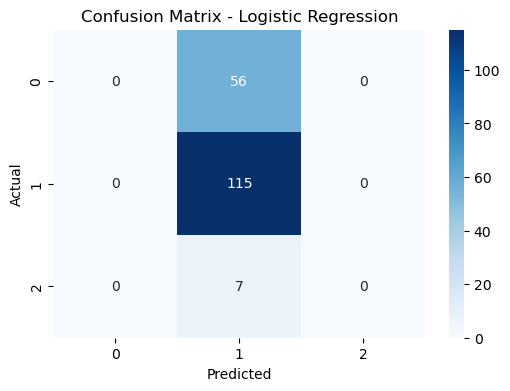

In [248]:

#Confusion matrix visualisation

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix - Logistic Regression")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


In [249]:

# FEATURE IMPORTANCE (COEFFICIENTS)

coefficients = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': model.coef_[0]
})

coefficients = coefficients.sort_values(by='Coefficient', ascending=False)

print("\n Feature Importance:")
print(coefficients)



 Feature Importance:
              Feature   Coefficient
112  ReportedDuration  7.944536e-07
109       distance_km  4.127636e-07
8             TimeCar  3.183638e-07
110     InVehicleTime  1.645995e-07
6              CostPT  1.212655e-07
..                ...           ...
114               age -2.850048e-07
3              TimePT -3.093764e-07
4       WalkingTimePT -3.401526e-07
27          BirthYear -1.167128e-05
32   CalculatedIncome -5.580049e-05

[117 rows x 2 columns]


In [250]:

#Showing which variable strongly influences the decision
    
# Impact of cluster

cluster_effect = coefficients[coefficients['Feature'] == 'Cluster']
print("\n Impact of Cluster on Choice:")
print(cluster_effect)



 Impact of Cluster on Choice:
     Feature   Coefficient
116  Cluster -2.501348e-08


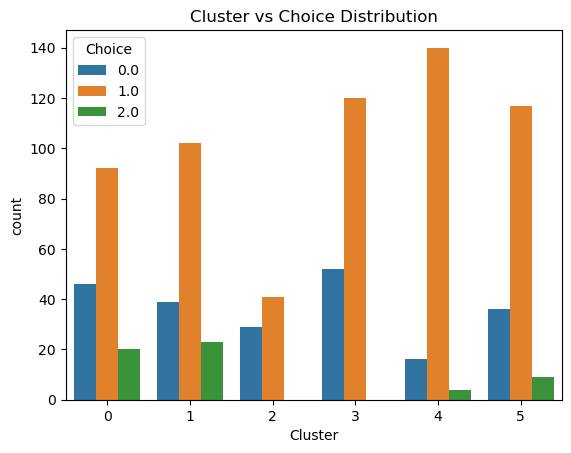

In [251]:
import seaborn as sns

plt.figure()
sns.countplot(x='Cluster', hue='Choice', data=df)
plt.title("Cluster vs Choice Distribution")
plt.show()

In [252]:
#top important features - Select top features based on the magnitude of their coefficients in a trained model
import pandas as pd

coefficients = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': model.coef_[0]
})

# Take absolute value (importance = magnitude)
coefficients['Importance'] = coefficients['Coefficient'].abs()

# Sort by importance
coefficients = coefficients.sort_values(by='Importance', ascending=False)

# Select top N features
top_n = 5
top_features = coefficients['Feature'].head(top_n).tolist()

print("Top Features:", top_features)



Top Features: ['CalculatedIncome', 'BirthYear', 'ReportedDuration', 'distance_km', 'WalkingTimePT']


In [253]:
for feature in top_features:
    plt.figure()
    plt.scatter(X_test[feature], y_prob)
    plt.xlabel(feature)
    plt.ylabel("Predicted Probability")
    plt.title(f"{feature} vs Predicted Probability (Top Feature)")
    plt.show()

NameError: name 'y_prob' is not defined

<Figure size 640x480 with 0 Axes>

In [ ]:
print(len(X.columns))
print ("\n")
for feature in X.columns:
    print(feature)

117


ID
DestAct
NbTransf
TimePT
WalkingTimePT
WaitingTimePT
CostPT
CostCar
TimeCar
NbHousehold
NbChild
NbCar
NbMoto
NbBicy
NbBicyChild
NbComp
NbTV
Internet
NewsPaperSubs
NbCellPhones
NbSmartPhone
HouseType
OwnHouse
NbRoomsHouse
YearsInHouse
Income
Gender
BirthYear
Mothertongue
FamilSitu
OccupStat
SocioProfCat
CalculatedIncome
Education
HalfFareST
LineRelST
GenAbST
AreaRelST
OtherST
CarAvail
MarginalCostPT
CostCarCHF
Envir01
Envir02
Envir03
Envir04
Envir05
Envir06
Mobil01
Mobil02
Mobil03
Mobil04
Mobil05
Mobil06
Mobil07
Mobil08
Mobil09
Mobil10
Mobil11
Mobil12
Mobil13
Mobil14
Mobil15
Mobil16
Mobil17
Mobil18
Mobil19
Mobil20
Mobil21
Mobil22
Mobil23
Mobil24
Mobil25
Mobil26
Mobil27
ResidCh01
ResidCh02
ResidCh03
ResidCh04
ResidCh05
ResidCh06
ResidCh07
LifSty01
LifSty02
LifSty03
LifSty04
LifSty05
LifSty06
LifSty07
LifSty08
LifSty09
LifSty10
LifSty11
LifSty12
LifSty13
LifSty14
TripPurpose
TypeCommune
UrbRur
LangCode
ClassifCodeLine
frequency
ResidChild
NbTrajects
FreqCarPar
FreqTrainPar
FreqOth

In [ ]:

print(" Final observations:")
print(" Accuracy:", accuracy)
print(" Confusion Matrix:\n", cm)
print(" Classification Report displayed above")
print(" Feature Importance extracted")
print(" Cluster impact analyzed")


 Final observations:
 Accuracy: 0.6460674157303371
 Confusion Matrix:
 [[  0  56   0]
 [  0 115   0]
 [  0   7   0]]
 Classification Report displayed above
 Feature Importance extracted
 Cluster impact analyzed


In [ ]:

# Additional:  multi collinearity analysis


import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np


#  Correlation matrix ( feature vs feature)


corr_matrix = X.corr()

plt.figure(figsize=(12,10))
sns.heatmap(corr_matrix, cmap='coolwarm', center=0)

plt.title("Correlation Matrix (Feature vs Feature)")
plt.show()

# ------------------------------------------------------------
# EXPLANATION:
# - Shows relationship between all independent variables
# - Helps detect multicollinearity
#
# INTERPRETATION:
# +1 → strong positive relationship
# -1 → strong negative relationship
#  0 → no relationship
#
# IMPORTANT:
# If two variables are highly correlated (>0.8),
# they may be redundant




#finding highly correlated variables

threshold = 0.8

corr_pairs = corr_matrix.abs().unstack()
corr_pairs = corr_pairs.sort_values(ascending=False)

# Removing self-correlation
corr_pairs = corr_pairs[corr_pairs < 1]

# Keeping only strong correlations
high_corr = corr_pairs[corr_pairs > threshold]

print("\n Highly Correlated Variable Pairs:\n")
print(high_corr)

# ------------------------------------------------------------
# EXPLANATION:
# - Converts matrix into list of variable pairs
# - Shows only strong correlations
#
# WHY:
# Easier than reading full heatmap
# ------------------------------------------------------------


#Multi-collinearity using VIF

from statsmodels.stats.outliers_influence import variance_inflation_factor
import statsmodels.api as sm

# Adding constant for VIF calculation
X_vif = sm.add_constant(X)

vif_data = pd.DataFrame()
vif_data["Feature"] = X_vif.columns

vif_data["VIF"] = [variance_inflation_factor(X_vif.values, i) 
                  for i in range(X_vif.shape[1])]

print("\n[IMPORTANT] Variance Inflation Factor (VIF):\n")
print(vif_data)

# WHAT IS VIF?
#
# VIF (Variance Inflation Factor) measures how much a variable
# is explained by other variables.
#
# INTERPRETATION:
# VIF = 1 → no correlation
# VIF < 5 → acceptable
# VIF > 10 → serious multicollinearity problem
#

# - High VIF → unstable model coefficients
# - Makes interpretation unreliable




# Relationship with the target variable ( other vairables bs choice variables)
# Combine X and y for analysis
df_analysis = X.copy()
df_analysis['Choice'] = y

# Computing correlation with target
target_corr = df_analysis.corr()['Choice'].sort_values(ascending=False)

print("\n Correlation with Target (Choice):\n")
print(target_corr)


# Shows how each variable affects Choice

# INTERPRETATION:
# Positive value → increases likelihood
# Negative value → decreases likelihood




#visualizing the main variables which are affecting the choices


top_features = target_corr.drop('Choice').head(10)

top_features.plot(kind='barh')
plt.title("Top Variables Influencing Choice")
plt.xlabel("Correlation Value")
plt.show()


#logistic regression coeffecients( model- based)

coefficients = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': model.coef_[0]
})

coefficients = coefficients.sort_values(by='Coefficient', ascending=False)

print("\n Logistic Regression Coefficients:\n")
print(coefficients)

# Shows actual impact in the model

# Positive coefficient → increases probability
# Negative coefficient → decreases probability
#
